# Deep Learning: Multilayer Artificial Neural Network

Trains the required Multilayer ANN on the same `features_train.csv` / `features_test.csv` used
by the classical models, so all four models are compared on an identical feature representation.

**Implementation note:** this uses `sklearn.neural_network.MLPClassifier` — a genuine multilayer,
fully-connected feedforward network trained by backpropagation, i.e. exactly what "Multilayer
ANN" refers to — rather than TensorFlow/Keras, which isn't installed in this environment. If your
team wants to extend this later with an LSTM or RNN (the assessment's optional "other Deep
Learning Algorithms" bonus), that would need Keras/TensorFlow and a sequential/time-series framing
of the data, which is a separate, larger piece of work beyond this notebook.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.neural_network import MLPClassifier

from helpers.nb_utils import evaluate_classifier, plot_confusion, save_metrics, load_all_metrics, PROC_DIR, FIG_DIR

pd.set_option("display.max_columns", 50)

## 1. Load features (already scaled and encoded by notebook 02)

In [2]:
train = pd.read_csv(PROC_DIR / "features_train.csv")
test = pd.read_csv(PROC_DIR / "features_test.csv")

ID_COLS = ["country", "cca3", "reference_year"]
TARGET = "target_exposure_class"
FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET]]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]
groups_train = train["cca3"]

# MLPClassifier's early-stopping path scores its internal validation split with
# a numpy check that doesn't handle string class labels in this sklearn version
# -- encoding the target to integers sidesteps that without changing anything
# about what the model learns. Predictions are mapped back to Low/Medium/High
# immediately after predicting, so every downstream cell still works with the
# same class labels as the other three models.
CLASS_TO_CODE = {"Low": 0, "Medium": 1, "High": 2}
CODE_TO_CLASS = {v: k for k, v in CLASS_TO_CODE.items()}
y_train_enc = y_train.map(CLASS_TO_CODE)

## 2. Keeping the network small on purpose

663 training rows (221 independent countries, repeated across three decades) is a small dataset
for a neural network, which typically wants far more examples than a tree-based model to find
stable weights. Going deep or wide here would mean more parameters than the data can meaningfully
constrain, which is a direct route to memorising the training set rather than learning a
generalisable pattern. So the search space below deliberately stays shallow (one or two hidden
layers, modest width), pairs with L2 regularisation (`alpha`) to further discourage over-fitting,
and turns on early stopping so training stops as soon as a held-out slice of the training data
stops improving — rather than running for a fixed number of epochs regardless.

The same grouped cross-validation from the previous notebook is reused here for the same reason:
a country's three decades shouldn\'t be split across train/validation during tuning.

In [3]:
cv = GroupKFold(n_splits=5)

mlp_grid = GridSearchCV(
    MLPClassifier(
        random_state=42,
        max_iter=2000,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.15,
    ),
    param_grid={
        "hidden_layer_sizes": [(8,), (16,), (16, 8), (32, 16)],
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    },
    scoring="f1_macro",
    cv=cv.split(X_train, y_train_enc, groups=groups_train),
    n_jobs=-1,
)
mlp_grid.fit(X_train, y_train_enc)
print("Best ANN architecture:", mlp_grid.best_params_)
print(f"Best cross-validated macro-F1: {mlp_grid.best_score_:.3f}")

ann_model = mlp_grid.best_estimator_

Best ANN architecture: {'alpha': 0.1, 'hidden_layer_sizes': (16,)}
Best cross-validated macro-F1: 0.424


## 3. Test-set evaluation

=== Multilayer ANN ===
              precision    recall  f1-score   support

         Low       0.22      0.32      0.26        62
      Medium       0.41      0.45      0.43        93
        High       0.30      0.14      0.19        66

    accuracy                           0.32       221
   macro avg       0.31      0.30      0.29       221
weighted avg       0.33      0.32      0.31       221

Saved metrics for 'Multilayer ANN' to /home/claude/project/outputs/results/model_metrics.json


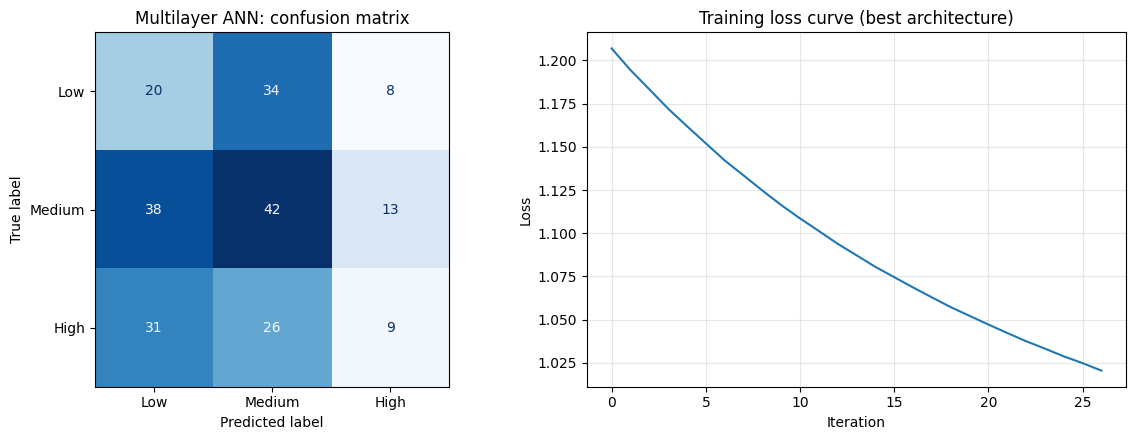

In [4]:
ann_pred = pd.Series(ann_model.predict(X_test)).map(CODE_TO_CLASS).to_numpy()
ann_metrics = evaluate_classifier("Multilayer ANN", y_test, ann_pred)
save_metrics(ann_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(y_test, ann_pred, title="Multilayer ANN: confusion matrix", ax=axes[0])
axes[1].plot(ann_model.loss_curve_)
axes[1].set_title("Training loss curve (best architecture)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_ann.png", dpi=200)
plt.show()

## 4. Where the ANN stands against the classical models so far

A quick look now, before the dedicated comparison notebook — useful to sanity-check the ANN
result isn't wildly out of line with the other three before moving on.

In [5]:
all_metrics = pd.DataFrame(load_all_metrics().values()).set_index("model")
display(all_metrics.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Decision Tree,0.439,0.455,0.441,0.446,0.448,0.439,0.442
Random Forest,0.421,0.437,0.437,0.426,0.430,0.421,0.415
Naive Bayes,0.389,0.539,0.437,0.318,0.554,0.389,0.283
Multilayer ANN,0.321,0.312,0.304,0.294,0.326,0.321,0.312


## Where this leaves you

- The ANN's metrics are now saved alongside the three classical models' in
  `outputs/results/model_metrics.json`.
- `05_model_comparison.ipynb` builds the final side-by-side comparison and chart for the
  presentation from that one shared file — nothing needs to be copied by hand between notebooks.
- If the ANN underperforms the Random Forest here, that is a defensible, explainable outcome
  given the dataset size (see the reasoning in Section 2) — not something to paper over.